In [1]:
import pandas as pd 
import numpy as np 
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F 
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv('Dataset/AEP_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')

# mengurutkan waktu dri terlama ke terbaru
df = df.sort_index()
df.head()


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [11]:
df.columns

Index(['AEP_MW'], dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB


In [13]:
df.isna().sum()

AEP_MW    0
dtype: int64

In [15]:
df.shape

(121273, 1)

### HYPERPARAMETER

In [ ]:
n_input = 24
n_nodes = 150
n_epochs = 100

## PREPROCESSING 

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [20]:
# TAHAP: DATA PREPROCESSING & FEATURE ENGINEERING (TIME SERIES TRANSFORMATION)

# Tujuan: Mengubah data deret waktu 1D menjadi format Supervised Learning (X -> y)

# 1. Ambil nilai kolom AEP_MW dan ubah ke 2D Array
data = df[['AEP_MW']].values

# 2. Scaling data ke rentang 0 - 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Definisi fungsi lo
def series_to_supervised(data, n_in, n_out=1):
    df = pd.DataFrame(data)
    cols = list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    agg = pd.concat(cols, axis=1)
    agg.dropna(inplace=True)
    return agg.values

# 4. Jalankan pakai n_in = 24
data_siap_pakai = series_to_supervised(scaled_data, 24)

# Cek bentuk dimensi data_siap_pakai (harus x baris, 25 kolom: 24 input + 1 target)
data_siap_pakai

array([[0.17363783, 0.14608415, 0.1310041 , ..., 0.27839146, 0.22129825,
        0.16625295],
       [0.14608415, 0.1310041 , 0.1251086 , ..., 0.22129825, 0.16625295,
        0.12976294],
       [0.1310041 , 0.1251086 , 0.13032146, ..., 0.16625295, 0.12976294,
        0.10990443],
       ...,
       [0.41057466, 0.3523644 , 0.28199082, ..., 0.50217202, 0.47921062,
        0.46046916],
       [0.3523644 , 0.28199082, 0.22992429, ..., 0.47921062, 0.46046916,
        0.39611518],
       [0.28199082, 0.22992429, 0.18654586, ..., 0.46046916, 0.39611518,
        0.32443838]], shape=(121249, 25))

In [21]:
# Memotong Data Menjadi Data Latihan & Data Ujian 

# 1. Pisahkan Feature (X) dan Target (y)
X = data_siap_pakai[:, :-1]  # Mengambil 24 kolom pertama
y = data_siap_pakai[:, -1]   # Mengambil 1 kolom paling akhir

# 2. Tentukan titik potong (80% Train, 20% Test)
train_size = int(len(X) * 0.8)

# 3. Bagi data Train dan Test
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Ukuran X_train: (96999, 24)
Ukuran X_test : (24250, 24)


## convert to Tensor PyTorch! 

- Sekarang datanya masih berupa NumPy array. Karena kita mau pakai PyTorch, kita harus ubah data $X$ dan $y$ ini ke format Tensor.

In [22]:
# Ubah ke PyTorch Tensor (Gunakan float32 agar cocok dengan bobot PyTorch)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32)

# Cek tipe data dan ukurannya
print("Tipe data X_train_tensor:", X_train_tensor.dtype)
print("Ukuran X_train_tensor   :", X_train_tensor.shape)

Tipe data X_train_tensor: torch.float32
Ukuran X_train_tensor   : torch.Size([96999, 24])


In [23]:
# ARSITEKTUR MODEL: Multi-Layer Perceptron (MLP) untuk Time Series

# 1. Definisi Arsitektur Model
class TimeSeriesMLPModel(nn.Module):
    def __init__(self, n_input, n_nodes) -> None:
        super().__init__()
        self.lm_linear = nn.Sequential(
            nn.Linear(in_features=n_input, out_features=n_nodes),
            nn.ReLU(),
            nn.Linear(in_features=n_nodes, out_features=1),
        )

    def forward(self, X):
        logits = self.lm_linear(X)
        return logits

In [24]:
# 2. Inisialisasi Model, Loss Function, dan Optimizer
model = TimeSeriesMLPModel(n_input=24, n_nodes=150)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training (Loop Epoch)

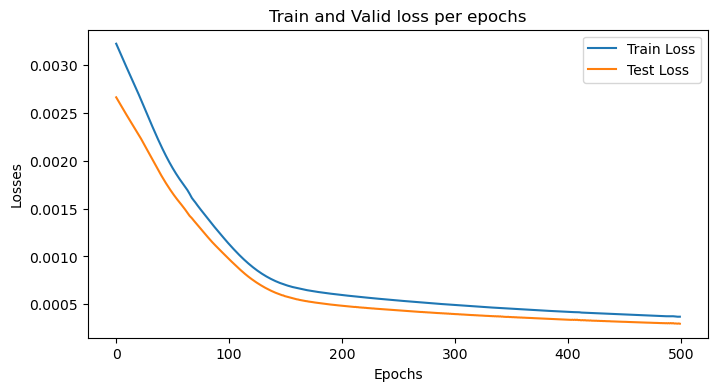

In [26]:
import matplotlib.pyplot as plt

# 1. Tentukan Epochs & Tempat Penampung Loss
n_epochs = 500
train_losses = []
test_losses = []

# 2. Loop Pelatihan & Validasi
for epoch in range(n_epochs):
    # A. TRAINING PHASE
    model.train()
    optimizer.zero_grad()
    
    # Tebak & hitung error latihan
    train_pred = model(X_train_tensor)
    train_loss = criterion(train_pred, y_train_tensor.unsqueeze(1))
    
    # Update bobot model
    train_loss.backward()
    optimizer.step()
    
    # B. TESTING / VALIDATION PHASE (Simpel, langsung tes sekaligus!)
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor.unsqueeze(1))
        
    # Catat Rekam Eror
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

# 3. PLOTTING GRAFIK
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.title('Train and Valid loss per epochs')
plt.legend()
plt.show()

In [27]:
# Cek 1 sampel pertama dari data tensor kamu
X_train_tensor[0], y_train_tensor[0]

(tensor([0.1736, 0.1461, 0.1310, 0.1251, 0.1303, 0.1675, 0.2551, 0.3126, 0.3303,
         0.3436, 0.3513, 0.3596, 0.3614, 0.3769, 0.3822, 0.3822, 0.3763, 0.3582,
         0.3384, 0.3494, 0.3579, 0.3262, 0.2784, 0.2213]),
 tensor(0.1663))

In [29]:
X_train_tensor[1], y_train_tensor[1]

(tensor([0.1461, 0.1310, 0.1251, 0.1303, 0.1675, 0.2551, 0.3126, 0.3303, 0.3436,
         0.3513, 0.3596, 0.3614, 0.3769, 0.3822, 0.3822, 0.3763, 0.3582, 0.3384,
         0.3494, 0.3579, 0.3262, 0.2784, 0.2213, 0.1663]),
 tensor(0.1298))

In [30]:
# INSPEKSI DATA: Membuat & Mengecek Dimensi Modal Awal Prediksi

# 1. Menggabungkan data latihan terakhir (24 jam X + 1 jam Y = 25 data)
# .numpy() dipakai jika X_train_tensor dan y_train_tensor kamu bentuknya PyTorch Tensor
history = X_train_tensor[-1].tolist() + [y_train_tensor[-1].item()]

# 2. Cek jumlah total data awal (Harusnya bernilai 25)
print("Total panjang history:", len(history))

# 3. Ambil 24 data terakhir (n_input), ubah ke Tensor, lalu cek bentuk dimensinya
modal_awal = torch.tensor(history[-24:], dtype=torch.float32)

print("Bentuk dimensi modal awal:", modal_awal.shape)

Total panjang history: 25
Bentuk dimensi modal awal: torch.Size([24])


In [32]:
# 1. Soal (24 jam) pertama di data uji
print("Input X_test pertama  :", X_test_tensor[0])

# 2. Jawaban asli (target y) pertama di data uji
print("Target y_test pertama :", y_test_tensor[0])

Input X_test pertama  : tensor([0.2711, 0.2611, 0.2551, 0.2567, 0.2847, 0.3200, 0.3105, 0.2732, 0.2256,
        0.1818, 0.1435, 0.1314, 0.1172, 0.1253, 0.1364, 0.1863, 0.2762, 0.3280,
        0.3262, 0.3454, 0.3236, 0.3188, 0.3170, 0.3120])
Target y_test pertama : tensor(0.3027)


In [33]:
# 1. Menyiapkan modal history awal (24 jam X_train terakhir + 1 jam y_train terakhir)
history = X_train_tensor[-1].tolist() + [y_train_tensor[-1].item()]

y_pred_values = []
y_true = []

# 2. Evaluasi tanpa menghitung gradient (hemat memori & cepat)
model.eval()
with torch.no_grad():
    for i in range(len(y_test_tensor)):
        # Ambil 24 jam terakhir dari history
        test_points = torch.tensor(history[-24:], dtype=torch.float32).view(1, 24)
        
        # Model memprediksi 1 jam ke depan
        yhat = model(test_points)
        
        # Ambil nilai target asli jam tersebut
        actual_val = y_test_tensor[i].item()
        
        # Update history dengan nilai asli untuk modal tebakan berikutnya
        history.append(actual_val)
        
        # Simpan tebakan dan nilai asli
        y_pred_values.append(yhat.item())
        y_true.append(actual_val)

# 3. Ubah ke Tensor & Hitung Test Loss
y_pred_tensor = torch.tensor(y_pred_values, dtype=torch.float32)
y_true_tensor = torch.tensor(y_true, dtype=torch.float32)

test_loss = criterion(y_pred_tensor, y_true_tensor)
print(f"Test loss : {test_loss.item():.6f}")

Test loss : 0.000298


### insight

- Nilai Loss sebesar 0.000298 (sekitar $0.03\%$) menandakan bahwa selisih antara tebakan model dan data asli di data uji (Test Set) hampir mendekati nol.
- Model sukses besar dalam mempelajari pola pergerakan beban listrik jam-jaman dari data riwayat 24 jam sebelumnya.